In [1]:
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

EMBED_DIR = "outputs/embeddings"
OUTPUT_DIR = "outputs/surrogates"
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
METRICS_DIR = os.path.join(OUTPUT_DIR, "metrics")
PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
PRED_DIR = os.path.join(OUTPUT_DIR, "predictions")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

SEED = 42

In [2]:
# Load embeddings and metadata
X_train = np.load(os.path.join(EMBED_DIR, "train_embeddings.npy"))
X_val = np.load(os.path.join(EMBED_DIR, "val_embeddings.npy"))
X_test = np.load(os.path.join(EMBED_DIR, "test_embeddings.npy"))

train_meta = pd.read_csv(os.path.join(EMBED_DIR, "train_metadata.csv"))
val_meta = pd.read_csv(os.path.join(EMBED_DIR, "val_metadata.csv"))
test_meta = pd.read_csv(os.path.join(EMBED_DIR, "test_metadata.csv"))

# Surrogate classification target:
# The surrogate imitates the CNN's predicted class.
y_train_class = train_meta["cnn_prediction"].values
y_val_class = val_meta["cnn_prediction"].values
y_test_class = test_meta["cnn_prediction"].values

# Surrogate regression target:
# The surrogate imitates the CNN's TB probability.
y_train_prob = train_meta["cnn_probability_tb"].values
y_val_prob = val_meta["cnn_probability_tb"].values
y_test_prob = test_meta["cnn_probability_tb"].values

print("Train embeddings:", X_train.shape)
print("Val embeddings:", X_val.shape)
print("Test embeddings:", X_test.shape)

# Scale embeddings for Logistic Regression and Ridge
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, os.path.join(MODEL_DIR, "embedding_scaler.joblib"))

# Helper functions
def evaluate_classifier(model_name, model, X_test_input, y_test_target):
    pred = model.predict(X_test_input)

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test_input)[:, 1]
    else:
        prob = pred
    accuracy = accuracy_score(y_test_target, pred)
    precision = precision_score(y_test_target, pred, zero_division=0)
    recall = recall_score(y_test_target, pred, zero_division=0)
    f1 = f1_score(y_test_target, pred, zero_division=0)

    try:
        auc = roc_auc_score(y_test_target, prob)
    except ValueError:
        auc = 0.0
        
    cm = confusion_matrix(y_test_target, pred)
    metrics = {
        "model": model_name,
        "fidelity_accuracy": accuracy,
        "fidelity_precision": precision,
        "fidelity_recall": recall,
        "fidelity_f1": f1,
        "fidelity_auc": auc
    }
    pred_df = test_meta.copy()
    pred_df[f"{model_name}_prediction"] = pred
    pred_df[f"{model_name}_probability_tb"] = prob

    pred_df.to_csv(
        os.path.join(PRED_DIR, f"{model_name}_classification_predictions.csv"),
        index=False
    )
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["Surrogate Non-TB", "Surrogate TB"],
        yticklabels=["CNN Non-TB", "CNN TB"]
    )
    plt.title(f"{model_name} Fidelity Confusion Matrix")
    plt.xlabel("Surrogate Prediction")
    plt.ylabel("DenseNet121 Prediction")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f"{model_name}_fidelity_confusion_matrix.png"))
    plt.close()
    return metrics


def evaluate_regressor(model_name, model, X_test_input, y_test_target):
    pred_prob = model.predict(X_test_input)

    # Keep probabilities in valid range
    pred_prob = np.clip(pred_prob, 0, 1)

    mae = mean_absolute_error(y_test_target, pred_prob)
    mse = mean_squared_error(y_test_target, pred_prob)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_target, pred_prob)

    correlation = np.corrcoef(y_test_target, pred_prob)[0, 1]

    metrics = {
        "model": model_name,
        "probability_mae": mae,
        "probability_mse": mse,
        "probability_rmse": rmse,
        "probability_r2": r2,
        "probability_correlation": correlation
    }

    pred_df = test_meta.copy()
    pred_df[f"{model_name}_probability_tb"] = pred_prob
    pred_df[f"{model_name}_probability_error"] = np.abs(y_test_target - pred_prob)

    pred_df.to_csv(
        os.path.join(PRED_DIR, f"{model_name}_probability_predictions.csv"),
        index=False
    )

    plt.figure(figsize=(6, 6))
    plt.scatter(y_test_target, pred_prob, alpha=0.7)
    plt.xlabel("DenseNet121 TB Probability")
    plt.ylabel(f"{model_name} TB Probability")
    plt.title(f"{model_name}: Probability Imitation")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f"{model_name}_probability_scatter.png"))
    plt.close()

    return metrics

Train embeddings: (560, 1024)
Val embeddings: (120, 1024)
Test embeddings: (120, 1024)


In [4]:
# 1. Logistic Regression Classifier
log_reg = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=SEED
)

log_reg.fit(X_train_scaled, y_train_class)

joblib.dump(
    log_reg,
    os.path.join(MODEL_DIR, "logistic_regression_surrogate.joblib")
)

log_reg_metrics = evaluate_classifier(
    "logistic_regression",
    log_reg,
    X_test_scaled,
    y_test_class
)

# 2. Ridge Regression Probability Surrogate
ridge = Ridge(alpha=1.0, random_state=SEED)

ridge.fit(X_train_scaled, y_train_prob)

joblib.dump(
    ridge,
    os.path.join(MODEL_DIR, "ridge_probability_surrogate.joblib")
)

ridge_metrics = evaluate_regressor(
    "ridge_regression",
    ridge,
    X_test_scaled,
    y_test_prob
)

# 3. Decision Tree Classifier
tree_clf = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=5,
    random_state=SEED
)

tree_clf.fit(X_train, y_train_class)

joblib.dump(
    tree_clf,
    os.path.join(MODEL_DIR, "decision_tree_surrogate.joblib")
)

tree_clf_metrics = evaluate_classifier(
    "decision_tree",
    tree_clf,
    X_test,
    y_test_class
)
# 4. Decision Tree Regressor
tree_reg = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=5,
    random_state=SEED
)

tree_reg.fit(X_train, y_train_prob)

joblib.dump(
    tree_reg,
    os.path.join(MODEL_DIR, "decision_tree_probability_surrogate.joblib")
)

tree_reg_metrics = evaluate_regressor(
    "decision_tree_regressor",
    tree_reg,
    X_test,
    y_test_prob
)

# Save metrics
classification_metrics = pd.DataFrame([
    log_reg_metrics,
    tree_clf_metrics
])

regression_metrics = pd.DataFrame([
    ridge_metrics,
    tree_reg_metrics
])

classification_metrics.to_csv(
    os.path.join(METRICS_DIR, "surrogate_classification_fidelity_metrics.csv"),
    index=False
)

regression_metrics.to_csv(
    os.path.join(METRICS_DIR, "surrogate_probability_fidelity_metrics.csv"),
    index=False
)

print("\nClassification Fidelity Metrics:")
print(classification_metrics)

print("\nProbability Fidelity Metrics:")
print(regression_metrics)


Classification Fidelity Metrics:
                 model  fidelity_accuracy  fidelity_precision  \
0  logistic_regression           0.983333            0.964912   
1        decision_tree           0.925000            0.942308   

   fidelity_recall  fidelity_f1  fidelity_auc  
0         1.000000     0.982143      0.997203  
1         0.890909     0.915888      0.921958  

Probability Fidelity Metrics:
                     model  probability_mae  probability_mse  \
0         ridge_regression         0.112914         0.026461   
1  decision_tree_regressor         0.095751         0.036968   

   probability_rmse  probability_r2  probability_correlation  
0          0.162669        0.859287                 0.934370  
1          0.192270        0.803415                 0.913995  


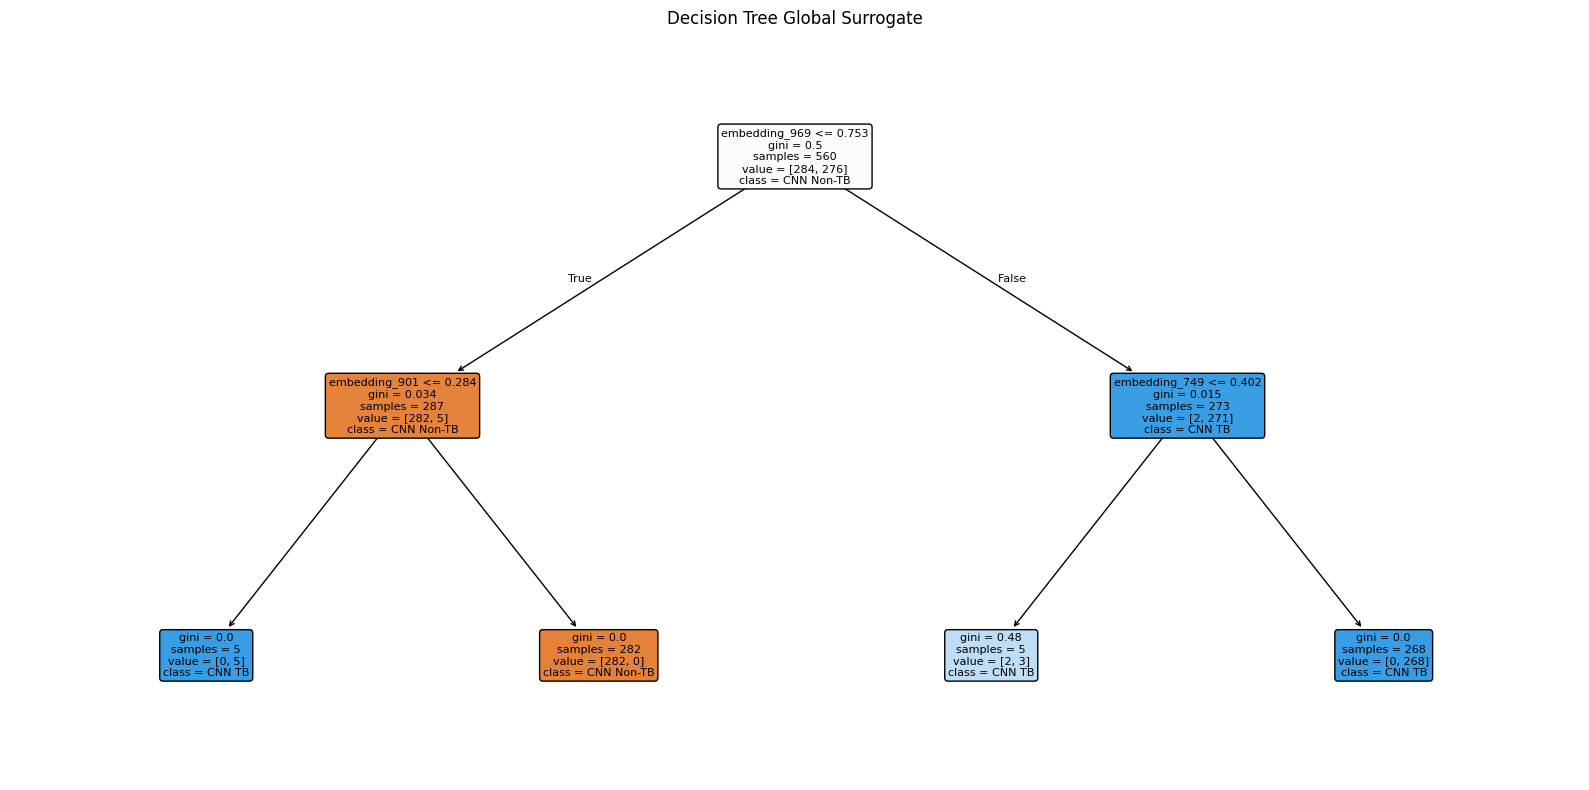

In [8]:
# Plot Decision Tree
plt.figure(figsize=(16, 8))
plot_tree(
    tree_clf,
    max_depth=3,
    filled=True,
    feature_names=[f"embedding_{i}" for i in range(X_train.shape[1])],
    class_names=["CNN Non-TB", "CNN TB"],
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Global Surrogate")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "decision_tree_surrogate_plot.png"), dpi=300)
plt.show()